In [1]:
# Import required libraries
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import tensorflow as tf
from tensorflow import keras

In [2]:
# Load and preprocess the dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Q: When do you use Dropout, Batch Normalization, and L1/L2 Regularization?

Dropout is used to reduce overfitting by randomly deactivating a fraction of neurons during training, forcing the network to learn robust features instead of relying on specific neurons.

Batch Normalization is used to normalize the activations of each mini-batch, making training faster and more stable. It often allows higher learning rates and can provide a small regularization effect.

L1 Regularization adds the absolute value of weights to the loss function, encouraging many weights to become exactly zero. It is useful for feature selection and sparse models.

L2 Regularization adds the squared value of weights to the loss function, reducing large weights without forcing them to zero. It is the most commonly used regularization technique to improve generalization.

In practice, Batch Normalization and L2 Regularization are commonly used together, and Dropout is added when the model still shows signs of overfitting, especially in larger neural networks.

In [8]:
from tensorflow.keras import regularizers

model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],),
                       kernel_regularizer=regularizers.l1_l2(l1=0.001, l2=0.001)),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu',
                       kernel_regularizer=regularizers.l1_l2(l1=0.001, l2=0.001)),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(16, activation='relu',
                       kernel_regularizer=regularizers.l1_l2(l1=0.001, l2=0.001)),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(1, activation='sigmoid')
])


C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(optimizer = 'adam', loss = 'binary_crossentropy',metrics = ['accuracy'])

In [11]:
history = model.fit(X_train,y_train,epochs = 10,batch_size = 32,validation_split = 0.2,verbose = 1)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.7115 - loss: 1.2455 - val_accuracy: 0.7033 - val_loss: 1.2737
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8132 - loss: 1.1232 - val_accuracy: 0.9231 - val_loss: 1.1757
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8846 - loss: 1.0099 - val_accuracy: 0.9231 - val_loss: 1.0969
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9231 - loss: 0.9477 - val_accuracy: 0.9341 - val_loss: 1.0334
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9258 - loss: 0.9300 - val_accuracy: 0.9341 - val_loss: 0.9787
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9368 - loss: 0.8797 - val_accuracy: 0.9451 - val_loss: 0.9381
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9451 - loss: 0.8538 - val_accuracy: 0.9341 - val_loss: 0.9072
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9451 - loss: 0.8298 - val_accuracy: 0.9451 - val_

In [12]:
# Evaluate the model and show performance metrics
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

acc = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f'Accuracy: {acc:.4f}')
print('Classification Report:')
print(report)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Accuracy: 0.9737
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        43
           1       0.96      1.00      0.98        71

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



# Deep Learning Classification with ANN
This workflow loads the breast cancer dataset from scikit-learn, preprocesses it, builds and trains an Artificial Neural Network (ANN) using TensorFlow/Keras, and evaluates the model using accuracy and classification report.

In [13]:
# Print training and validation accuracy
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

print('Training Accuracy for each epoch:')
print(train_acc)
print('\nValidation Accuracy for each epoch:')
print(val_acc)

print(f'Final Training Accuracy: {train_acc[-1]:.4f}')
print(f'Final Validation Accuracy: {val_acc[-1]:.4f}')

Training Accuracy for each epoch:
[0.7115384340286255, 0.8131868243217468, 0.8846153616905212, 0.9230769276618958, 0.9258241653442383, 0.9368131756782532, 0.9450549483299255, 0.9450549483299255, 0.9560439586639404, 0.9478021860122681]

Validation Accuracy for each epoch:
[0.7032967209815979, 0.9230769276618958, 0.9230769276618958, 0.9340659379959106, 0.9340659379959106, 0.9450549483299255, 0.9340659379959106, 0.9450549483299255, 0.9450549483299255, 0.9450549483299255]
Final Training Accuracy: 0.9478
Final Validation Accuracy: 0.9451


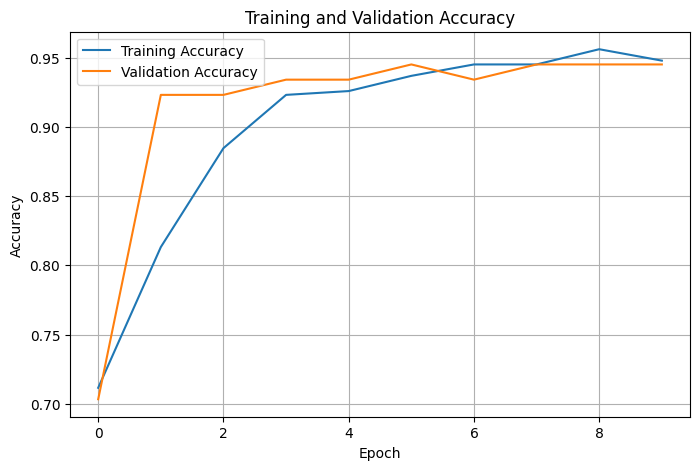

In [14]:
# Visualize training and validation accuracy using matplotlib
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
# Add EarlyStopping callback to stop training when validation accuracy stops improving
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
    callbacks=[early_stop]
)

# Find the epoch where training stopped
stopped_epoch = len(history.history['accuracy'])
print(f'Training stopped at epoch: {stopped_epoch}')
print(f'Best Validation Accuracy: {max(history.history["val_accuracy"]):.4f}')

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9588 - loss: 0.7716 - val_accuracy: 0.9560 - val_loss: 0.8147
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9615 - loss: 0.7702 - val_accuracy: 0.9560 - val_loss: 0.7977
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9808 - loss: 0.7205 - val_accuracy: 0.9560 - val_loss: 0.7790
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9643 - loss: 0.7234 - val_accuracy: 0.9560 - val_loss: 0.7650
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9670 - loss: 0.7184 - val_accuracy: 0.9560 - val_loss: 0.7502
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9725 - loss: 0.6965 - val_accuracy: 0.9560 - val_loss: 0.7393
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9615 - loss: 0.7247 - val_accuracy: 0.9560 - val_loss: 0.7262
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9615 - loss: 0.6843 - val_accuracy: 0.

In binary classification -- u will have 1 output neuron with sigmoid activation function

In Multi class classification -- u will have multiple output neurons with softmax activation function

# How the final output(class label) is represented in both cases
in Binary classification -- if the output is greater than 0.5, classify as class 1, else class 0

In Multi class classification -- the class with the highest probability is chosen as the predicted class

                    clas0  class1
In Binary class -- [0.4,   0.6]-- class 1

                    class0 class1 class2
In multi class  -- [0.1, 0.7, 0.2] -- class 1

                    class0 class1 class2
In multi class  -- [0.15, 0.25, 0.6] -- class 2

# Multi-Class Classification with Deep Learning
This section demonstrates building and training an ANN for multi-class classification using the scikit-learn digits dataset, with Dropout, BatchNormalization, and L1/L2 regularization, including early stopping and performance visualization.

In [16]:
# Load and preprocess the digits dataset for multi-class classification
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Load and preprocess the iris dataset for multi-class classification
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.utils import to_categorical


In [17]:
iris = load_iris()
X = iris.data
y = iris.target

# One-hot encode the target labels
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

In [18]:
# For keras, use to_categorical for one-hot encoding
y_encoded = to_categorical(y_encoded)

In [19]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
y_test

array([[0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.]])

In [21]:
X_test

array([[ 0.35451684, -0.58505976,  0.55777524,  0.02224751],
       [-0.13307079,  1.65083742, -1.16139502, -1.17911778],
       [ 2.30486738, -1.0322392 ,  1.8185001 ,  1.49058286],
       [ 0.23261993, -0.36147005,  0.44316389,  0.4227026 ],
       [ 1.2077952 , -0.58505976,  0.61508092,  0.28921757],
       [-0.49876152,  0.75647855, -1.27600637, -1.04563275],
       [-0.2549677 , -0.36147005, -0.07258719,  0.15573254],
       [ 1.32969211,  0.08570939,  0.78699794,  1.49058286],
       [ 0.47641375, -1.92659808,  0.44316389,  0.4227026 ],
       [-0.01117388, -0.80864948,  0.09932984,  0.02224751],
       [ 0.84210448,  0.30929911,  0.78699794,  1.09012776],
       [-1.23014297, -0.13788033, -1.33331205, -1.44608785],
       [-0.37686461,  0.98006827, -1.39061772, -1.31260282],
       [-1.10824606,  0.08570939, -1.27600637, -1.44608785],
       [-0.86445224,  1.65083742, -1.27600637, -1.17911778],
       [ 0.59831066,  0.53288883,  0.55777524,  0.55618763],
       [ 0.84210448, -0.

In [22]:
# Build and train a more complex ANN model for multi-class classification
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping

In [23]:
model_mc = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],),
                      kernel_regularizer=regularizers.l1_l2(l1=0.001, l2=0.001)),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu',
                      kernel_regularizer=regularizers.l1_l2(l1=0.001, l2=0.001)),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(16, activation='relu',
                      kernel_regularizer=regularizers.l1_l2(l1=0.001, l2=0.001)),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(3, activation='softmax')
])

C:\Users\DELL\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:

# for binary classificatio --  keras.layers.Dense(1, activation='sigmoid')  -- 2 classes present int the target column
# multi class classification -- keras.layers.Dense(15, activation='softmax') -- 15 classes present in the target column

In [25]:
model_mc.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stop_mc = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1)

history_mc = model_mc.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1,
    callbacks=[early_stop_mc]
)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.2604 - loss: 2.1414 - val_accuracy: 0.2500 - val_loss: 1.5966
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4167 - loss: 1.6323 - val_accuracy: 0.4167 - val_loss: 1.5550
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5104 - loss: 1.3836 - val_accuracy: 0.5417 - val_loss: 1.5167
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6042 - loss: 1.3038 - val_accuracy: 0.7500 - val_loss: 1.4701
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7396 - loss: 1.0685 - val_accuracy: 0.8750 - val_loss: 1.4177
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7604 - loss: 1.0080 - val_accuracy: 0.9583 - val_loss: 1.3630
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7708 - loss: 0.9580 - val_accuracy: 0.9583 - val_loss: 1.3157
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8229 - loss: 0.8959 - val_accuracy: 0.9583 - val_loss:

In [26]:

stopped_epoch_mc = len(history_mc.history['accuracy'])
print(f'Training stopped at epoch: {stopped_epoch_mc}')
print(f'Best Validation Accuracy: {max(history_mc.history["val_accuracy"]):.4f}')

Training stopped at epoch: 25
Best Validation Accuracy: 1.0000


In [27]:
# Evaluate the multi-class model and show performance metrics
import numpy as np
from sklearn.metrics import classification_report, accuracy_score

y_pred_prob_mc = model_mc.predict(X_test)
y_pred_mc = np.argmax(y_pred_prob_mc, axis=1)
y_true_mc = np.argmax(y_test, axis=1)

acc_mc = accuracy_score(y_true_mc, y_pred_mc)
report_mc = classification_report(y_true_mc, y_pred_mc)

print(f'Accuracy: {acc_mc:.4f}')
print('Classification Report:')
print(report_mc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step
Accuracy: 0.9667
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.89      0.94         9
           2       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



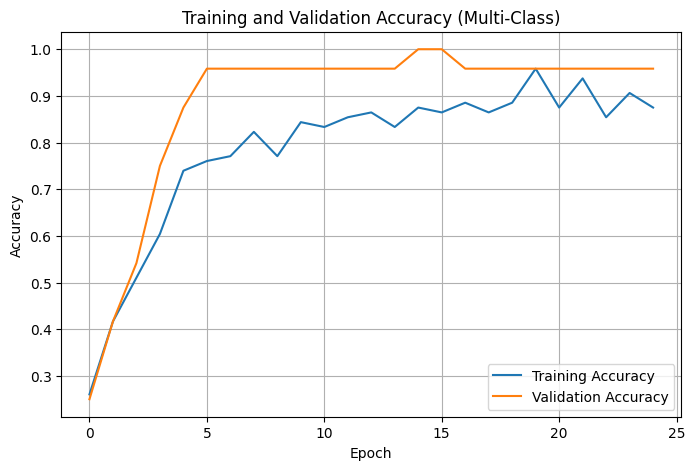

In [28]:
# Visualize training and validation accuracy for multi-class classification
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history_mc.history['accuracy'], label='Training Accuracy')
plt.plot(history_mc.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy (Multi-Class)')
plt.legend()
plt.grid(True)
plt.show()

# Activation Functions in Deep Learning: Evolution and Explanation

## 1. Step Function
- **Description:** The earliest activation function, used in perceptrons. Outputs 0 or 1 based on a threshold.
- **Limitation:** Not differentiable, so not suitable for gradient-based learning.

## 2. Sigmoid Function
- **Formula:** $\sigma(x) = \frac{1}{1 + e^{-x}}$
- **Description:** Smooth, differentiable, outputs between 0 and 1. Used for binary classification.
- **Limitation:** Prone to vanishing gradients for large/small inputs.

## 3. Tanh (Hyperbolic Tangent)
- **Formula:** $tanh(x) = \frac{e^{x} - e^{-x}}{e^{x} + e^{-x}}$
- **Description:** Outputs between -1 and 1. Zero-centered, helps with faster convergence than sigmoid.
- **Limitation:** Still suffers from vanishing gradients.

## 4. ReLU (Rectified Linear Unit)
- **Formula:** $f(x) = max(0, x)$
- **Description:** Most popular for hidden layers. Fast, simple, and helps mitigate vanishing gradient problem.
- **Limitation:** Can cause "dead neurons" (outputs always zero for negative inputs).

## 5. Leaky ReLU
- **Formula:** $f(x) = x$ if $x > 0$, else $\alpha x$ (typically $\alpha=0.01$)
- **Description:** Fixes dead neuron problem by allowing a small, non-zero gradient for negative inputs.

## 6. Softmax
- **Formula:** $softmax(x_i) = \frac{e^{x_i}}{\sum_{j} e^{x_j}}$
- **Description:** Used in output layer for multi-class classification. Converts outputs to probability distribution.

## 7. Swish, GELU, and Other Modern Activations
- **Swish:** $f(x) = x \cdot \sigma(x)$
- **GELU (Gaussian Error Linear Unit):** $f(x) = x \cdot \Phi(x)$, where $\Phi(x)$ is the cumulative distribution function of the standard normal distribution.
- **Description:** These newer functions combine properties of ReLU and sigmoid/tanh for better performance in deep networks.

---
**Summary Table:**
| Activation | Range      | Use Case                | Key Property           |
|------------|-----------|-------------------------|-----------------------|
| Step       | 0, 1      | Perceptron (obsolete)   | Non-differentiable    |
| Sigmoid    | 0 to 1    | Binary classification   | Smooth, vanishing grad|
| Tanh       | -1 to 1   | Hidden layers           | Zero-centered         |
| ReLU       | 0 to inf  | Hidden layers           | Fast, sparse          |
| Leaky ReLU | -inf to inf| Hidden layers           | Fixes dead neurons    |
| Softmax    | 0 to 1    | Multi-class output      | Probabilities         |
| Swish/GELU | -inf to inf| Deep networks           | Modern, adaptive      |


# cant we use sigmoid and softmax in our hidden layers
Ans: While technically possible, it is generally not recommended to use sigmoid or 
softmax activation functions in hidden layers of a neural network.


No, sigmoid and softmax are generally not recommended for hidden layers in deep learning models.

Sigmoid in hidden layers can cause vanishing gradients, making training slow and less effective.
Softmax is designed for output layers to produce a probability distribution over classes, not for hidden layers.
For hidden layers, functions like ReLU, Leaky ReLU, or tanh are preferred because they help gradients flow better and speed up training.

You should use:

ReLU/Leaky ReLU/tanh for hidden layers.
Sigmoid for binary classification output.
Softmax for multi-class classification output.

# Optimizers in Deep Learning: Evolution and Explanation

## 1. Gradient Descent (GD)
- **Description:** The original optimizer. Updates weights by computing the gradient of the loss function for the entire dataset.
- **Limitation:** Slow for large datasets, not practical for deep learning.

## 2. Stochastic Gradient Descent (SGD)
- **Description:** Updates weights using the gradient from a single randomly selected data point at each step.
- **Advantage:** Faster and more scalable than GD, introduces noise that can help escape local minima.
- **Limitation:** Can be noisy and unstable, may require careful tuning of learning rate.

## 3. Mini-Batch Gradient Descent
- **Description:** Compromise between GD and SGD. Updates weights using a small batch of data points.
- **Advantage:** More stable than SGD, faster than GD, commonly used in practice.

## 4. Momentum
- **Description:** Adds a fraction of the previous update to the current update, helping accelerate SGD in relevant directions and dampen oscillations.
- **Formula:** $v_t = \gamma v_{t-1} + \eta \nabla_w J(w)$
- **Advantage:** Helps speed up convergence and escape local minima.

## 5. Nesterov Accelerated Gradient (NAG)
- **Description:** Improves momentum by looking ahead at the future position of the parameters.
- **Advantage:** More responsive to changes in the gradient, can lead to faster convergence.

## 6. Adagrad
- **Description:** Adapts the learning rate for each parameter based on the historical gradients.
- **Advantage:** Good for sparse data, automatically adjusts learning rate.
- **Limitation:** Learning rate can become very small over time.

## 7. RMSprop
- **Description:** Fixes Adagrad's diminishing learning rate by using a moving average of squared gradients.
- **Advantage:** Works well for non-stationary objectives, commonly used for RNNs.

## 8. Adam (Adaptive Moment Estimation)
- **Description:** Combines ideas from RMSprop and Momentum. Maintains moving averages of both the gradients and their squares.
- **Advantage:** Most popular optimizer for deep learning, works well in practice, requires little tuning.

## 9. Nadam
- **Description:** Adam with Nesterov momentum.
- **Advantage:** Sometimes converges faster than Adam.

## 10. Other Modern Optimizers
- **Examples:** AdaMax, AMSGrad, LAMB, etc.
- **Description:** Variants and improvements for specific scenarios, large batch training, or better generalization.

---
**Summary Table:**
| Optimizer   | Key Feature                | Use Case/Notes                |
|-------------|---------------------------|-------------------------------|
| GD          | Full dataset gradient      | Not used for deep learning    |
| SGD         | Single sample update       | Fast, noisy, needs tuning     |
| Mini-Batch  | Small batch update         | Most common in practice       |
| Momentum    | Uses previous update       | Faster, escapes local minima  |
| NAG         | Lookahead momentum         | More responsive               |
| Adagrad     | Adaptive learning rate     | Sparse data, learning rate decay|
| RMSprop     | Moving avg of gradients    | RNNs, non-stationary problems |
| Adam        | RMSprop + Momentum         | Most popular, robust          |
| Nadam       | Adam + Nesterov            | Sometimes faster than Adam    |
| Others      | Specialized improvements   | Large batch, generalization   |
